## Points to improve
- ~make a class object for mapping floods and push everything in the backend.~
- ~dry dates should be taken from the attributes of the shapefile.~
- ~processed images (tile) should be stored in a json file.~
- ~flood map tiles have a gap in between. Polygon dissolve will leave gap.~
- ~store polygon-wise cell-level mean and std values or all values in the dry period? If doing the first option, how to update with new images? No need to update for IFMIAP and have a static cell-level mean and std values?~
- ~flood maps are vertically flipped~
- ~In the json, if the id already exists, do not overwrite it.~
- ~sort JSON keys and values~
- ~after mean and std computation, check for dem~
    - ~clip and store the dem file for all given AOIs.~
    - ~If the clipped dem*.nc file exist for that aoi, don't redo, else do.~
- ~define a period for which wet scenes will be downloaded~
- ~map floods for each new scene for each tile~
    - ~if area of floods is GT certain threshold, then store the flood map, else skip~
    - ~write in a json file that for this aoi, the scene has already been evaluated for flood cells (have dry years in the filename)~
- ~add year range in json file name~
- ~add years in the file name in the exported .nc file~
- ~work in local UTM projection~
    - ~add elevation and slope mask to the workflow~
- ~flood raster smoothing instead of vector buffer (required only if there are gaps between tiles)~
- ~add start and end year of dry period to the flood extent files~
- ~add start and end wet years in the final_output files~
- ~make subfolders in the output folder for mean_std and flood~
- ~dissolve and merge shapefile date wise -- in the end~
- ~while debugging, check for floods in other parts of the country too~
- ~remove dependency on INDIA_GRID_SHAPEFILE_PATH defined in utils~
- ~add a self.flush_files method to delete all the files created by the instance of class~
- ~the utils.merge_flood_gdfs is sensitive to underscores in the file path, folder names also have underscores~
- ~add a method to create all necessary folders~
- ~make sure other functions make use of the preprocessing.clip_xarray_using_id function~
- add relative slope logic
- push low level code to utils and other relevant modules
- add the code (from Nidhin) to merge rasters of same date tile-wise
- raster cells are not perfectly aligned, try a different interpolation algorithm?

## Current roadblock
- time :/

## Interesting points
- The read_reproject function processed 84 scenes in 9 min 28 sec on local computer at overview level 3.
- reprojecting the image twice in the preprocessing.read_reproject function because estimate_utm_crs is giving wrong utm zone the first time, so we are doing twice and then it is working fine

In [1]:
import sys
sys.path.append('../')

from ifmiap import flood_mapper
from ifmiap import utils

/opt/homebrew/lib/python3.9/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
# create the flood mapper class
bihar_flood_mapper = flood_mapper(
    grid_shapefile = r'../resources/india_utm_fishnet.gpkg',
    grid_id_list = [378],
    dry_date_col = 'dry_month',
    id_col = 'ID',
    dry_years=[2019, 2019],
    dem_dir = r'../resources/dem/',
    wet_duration = ['2019/07', '2019/07']
)


In [3]:
%%time
bihar_flood_mapper.get_dry_dates()

if len(bihar_flood_mapper.aoi_ids_to_process) > 0:
    bihar_flood_mapper.generate_dry_date_ranges()
    bihar_flood_mapper.get_s1_items(dry_wet='dry')
    bihar_flood_mapper.read_scenes(dry_wet='dry', overview_level=3)
    bihar_flood_mapper.generate_mean_std_by_aoi()
else:
    bihar_flood_mapper.load_mean_std_by_aoi()
    
bihar_flood_mapper.prepare_dem()
bihar_flood_mapper.prepare_wet_scenes(overview_level=3)
bihar_flood_mapper.map_floods(vv_thd=2.5, vh_thd=2.5, dem_thd=100, slp_thd=25,
                              export_raster=True, export_vector=True, export_maps=False)

/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


DEM for tile ID 378 not found. Downloading...
Flood cells not found in 378_S1B_IW_GRDH_1SDV_20190725T120450_20190725T120510_017290_020841_rtc.
CPU times: user 47.7 s, sys: 6.87 s, total: 54.6 s
Wall time: 9min 26s


In [4]:
utils.merge_flood_gdfs(r'/Users/pratyusht/Documents/MapSolveAI/ifmiap/output/flood_vector',
                       date_index=5, delimiter='_')

In [43]:
bihar_flood_mapper.flush_output(remove_dem=True)

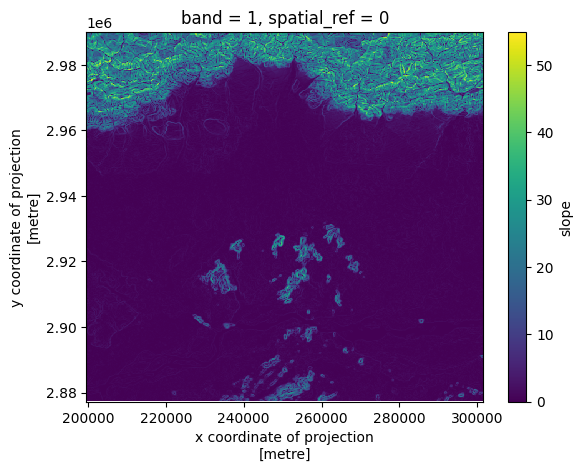

In [9]:
import xrspatial

slope_xarray = xrspatial.slope(bihar_flood_mapper.dem[378].squeeze())
slope_xarray.plot()

In [10]:
utils.export_xarray(slope_xarray, 
                   r'/Users/pratyusht/Documents/MapSolveAI/ifmiap/resources/dem/nasadem_slope_aoi_378.nc')

(704, 636)

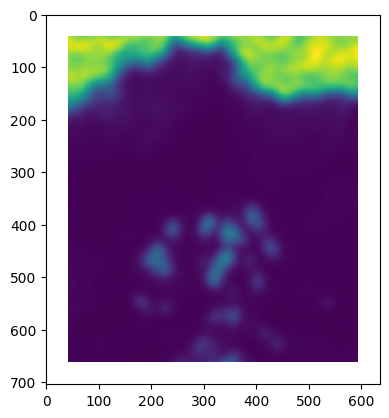

In [29]:
import numpy as np
from scipy import ndimage
from matplotlib import pyplot as plt

# Create a sample 2D NumPy array (replace this with your actual image data)
image_array = slope_xarray.values

# Apply Gaussian smoothing
sigma = 10  # Adjust the sigma parameter to control the amount of smoothing
smoothed_image = ndimage.gaussian_filter(image_array, sigma=sigma)

# smoothed_image now contains the smoothed version of your input image_array
plt.imshow(smoothed_image, interpolation='nearest')
plt.show()